<div class="alert alert-info" role="alert" style="padding:20px; margin-bottom:16px;">
  <div style="text-align:center;">
    <h1 style="margin:0;">Exploratory Data Analysis</h1>
    <div style="font-size:18px; margin-top:4px;">Amazing International Airlines Inc.</div>
    <div style="font-size:18px; margin-top:4px;">Clustering - Merge all perspectives</div>
    <hr style="margin:12px auto; width:220px;">
    <div style="font-size:14px; color:#6c757d;">Group 92 • Notebook • 2025/2026</div>
  </div>
</div>


This Project was done by:


Student Name    -   Mehmet Karaca;
student id      -   20250344;
contact email   -   20250344@novaims.unl.pt

Student Name    -   Duarte Gomes;
student id      -   20250017;
contact email   -   20250017@novaims.unl.pt

Student Name    -   Esra Salhi
student id      -   20250537
contact email   -   20250537@novaims.unl.pt

## Table of Contents



Add some contents here



# 1 Introduction <a id="introduction"></a>


## 1.1. Importing Libraries <a id="importing-libraries"></a>


In [1]:
# --- Standard Imports
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import matplotlib
import math
import matplotlib as mpl
from cycler import cycler
import geopandas as gpd
from matplotlib.lines import Line2D
from sklearn.impute import KNNImputer
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.base import clone
from scipy.cluster.hierarchy import dendrogram, linkage



In [2]:
import warnings

# Suppress FutureWarnings (covers the pandas 3.0 CoW warnings)
warnings.simplefilter(action='ignore', category=FutureWarning)

## 1.2. Loading and Reading Data <a id="loading-and-reading-data"></a>

In [3]:
# directory with raw CSV files
data_dir = Path("../data/cleanAndFeatureEngineered")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['DM_AIAI_FlightsDB_Cleaned_Featured.csv', 'DM_AIAI_CustomerDB_Cleaned_Featured.csv']


In [4]:
# specify the files we want to load

customers_file = data_dir / "DM_AIAI_CustomerDB_Cleaned_Featured.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB_Cleaned_Featured.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16375, 46)
Flights shape: (596664, 11)


## 1.3. Brief Preliminary Analysis <a id="brief-preliminary-analysis"></a>

In [5]:
customers.columns

Index(['Loyalty#', 'First Name', 'Last Name', 'Customer Name', 'Country',
       'City', 'Latitude', 'Longitude', 'Postal code', 'Income',
       'EnrollmentDateOpening', 'CancellationDate', 'Customer Lifetime Value',
       'IsActive', 'CustomerTenureDays', 'total_flights',
       'total_flights_with_companions', 'total_distance',
       'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'average_distance_per_flight',
       'points_redemption_ratio', 'companion_flight_ratio',
       'LoyaltyStatus_Nova', 'LoyaltyStatus_Star', 'EnrollmentType_Standard',
       'Gender_male', 'Education_College', 'Education_Doctor',
       'Education_High School or Below', 'Education_Master',
       'Marital Status_Married', 'Marital Status_Single',
       'Province or State_British Columbia', 'Province or State_Manitoba',
       'Province or State_New Brunswick', 'Province or State_Newfoundland',
       'Province or State_Nova Scotia', 'Province or State_Ontario',
     

In [6]:
flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed', 'Season'],
      dtype='object')

In [7]:
customers.describe(include='number')

,Loyalty#,Latitude,Longitude,Income,Customer Lifetime Value,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,...,Province or State_New Brunswick,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban
count,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,...,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000,16375.000000
mean,0.499368,0.236211,0.524848,0.377287,0.074718,0.874931,0.447696,0.469802,0.286013,0.406807,...,0.037924,0.015084,0.032122,0.322870,0.004031,0.196153,0.023878,0.006473,0.339053,0.326168
std,0.287477,0.186450,0.270156,0.303479,0.084015,0.330807,0.300579,0.200368,0.186693,0.227656,...,0.191018,0.121891,0.176330,0.467588,0.063360,0.397098,0.152673,0.080198,0.473402,0.468824
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.251407,0.070265,0.179966,0.000000,0.025561,1.000000,0.155718,0.355752,0.134454,0.215520,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.500480,0.174946,0.676108,0.341215,0.047687,1.000000,0.418491,0.507375,0.294118,0.467997,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.745929,0.355081,0.734242,0.623869,0.086445,1.000000,0.711273,0.627729,0.420168,0.580960,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 2. Best Clustering for each perspective <a class="anchor" id="data-validity-checks"></a>

The best Clustering methods for each perspective was found in the previous notebooks. This methods will be applied again to put a label for the dataset customer. All entries will get 3 labels (One from each method)

In [8]:
# Define feature categories from previous analysis

value_based_features = [
    'Customer Lifetime Value',
    'Income',
    'total_flights',
    'total_distance',
    'average_distance_per_flight',
    'total_points_accumulated',
    'total_cost_redeemed',
    'points_redemption_ratio',
    'IsActive',
    'EnrollmentType_Standard',
    'LoyaltyStatus_Nova',
    'LoyaltyStatus_Star'
]


demographic_features = [
    'Province or State_Newfoundland',
    'Province or State_Nova Scotia',
    'Province or State_Ontario',
    'Province or State_Prince Edward Island',
    'Province or State_Quebec',
    'Province or State_Saskatchewan',
    'Province or State_Yukon',
    'Location Code_Suburban',
    'Location Code_Urban',
    'Latitude',
    'Longitude',
    'Gender_male',
    'Education_College',
    'Education_High School or Below',
    'Education_Master',
    'Education_Doctor',
    'Income',
    'Marital Status_Married',
    'Marital Status_Single',
]


behavioral_features = [
    'total_flights',
    'total_flights_with_companions',
    'companion_flight_ratio',
    'average_distance_per_flight',
    'total_distance',
    'points_redemption_ratio',
    'IsActive',
    'CustomerTenureDays',
    'LoyaltyStatus_Nova',
    'LoyaltyStatus_Star'
]


### Clustering Strategy by Perspective

We have selected the optimal clustering algorithms for each customer data perspective based on evaluation metrics (Silhouette, Inertia) and data distribution.

| **Perspective** | **Selected Algorithm** | **Configuration / Notes** |
| :--- | :--- | :--- |
| **Value Based** | **Mean Shift** | `quantile=0.2` (Tighter bandwidth for density) |
| **Demographics** | **SOM (Two-Stage)** | Self Organizing Maps |
| **Behavioral** | **Mean Shift** | Uses default bandwidth estimation |

In [80]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. R2 Score (Angepasst für Clustering)
# Misst, wie viel Streuung durch die Cluster erklärt wird (1.0 = perfekt getrennt)
def calculate_clustering_r2(X, labels):
    # Sicherstellen, dass X ein Numpy Array ist
    data = X.values if hasattr(X, 'values') else X
    
    # Globaler Schwerpunkt (Centroid) und totale Varianz (SST)
    global_mean = np.mean(data, axis=0)
    sst = np.sum((data - global_mean) ** 2)
    
    # Varianz innerhalb der Cluster (SSW)
    ssw = 0
    unique_labels = np.unique(labels)
    
    for label in unique_labels:
        cluster_points = data[labels == label]
        cluster_mean = np.mean(cluster_points, axis=0)
        ssw += np.sum((cluster_points - cluster_mean) ** 2)
        
    return 1 - (ssw / sst)

# 2. Silhouette Score Wrapper
def get_silhouette_score(X, labels):
    # Prüfung: Silhouette braucht mindestens 2 Cluster
    if len(np.unique(labels)) < 2:
        return np.nan
    return silhouette_score(X, labels)

# 3. Davies-Bouldin Index Wrapper
def get_davies_bouldin_index(X, labels):
    # Prüfung: Braucht ebenfalls min. 2 Cluster
    if len(np.unique(labels)) < 2:
        return np.nan
    return davies_bouldin_score(X, labels)


# Cell 3: Helper functions from Labs 09-12

def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.
    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.
    
    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    return ss


def get_ssb(df, feats, label_col):
    """
    Calculate the between-group sum of squares (SSB) for the given DataFrame.
    The between-group sum of squares is computed as the sum of the squared differences
    between the mean of each group and the overall mean, weighted by the number of observations
    in each group.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column in the DataFrame that contains the group labels.
    
    Returns:
    float: The between-group sum of squares of the DataFrame.
    """
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))))
    
    ssb = np.sum(ssb_i)
    return ssb


def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.
    
    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats + [label_col]
    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats),
        include_groups=False
    )
    return df_k.sum()


def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.
    
    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """
    df_sst_ = get_ss(df, feats)  # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)  # get ss within
    df_ssb_ = df_sst_ - df_ssw_  # get ss between
    # r2 = ssb/sst
    return (df_ssb_ / df_sst_)


def get_r2_scores(df, feats, clusterer, min_k=1, max_k=9):
    """
    Loop over different values of k. To be used with sklearn clusterers.
    """
    r2_clust = {}
    for n in range(min_k, max_k):
        clust = clone(clusterer).set_params(n_clusters=n)
        labels = clust.fit_predict(df)
        df_concat = pd.concat([df,
                               pd.Series(labels, name='labels', index=df.index)], axis=1)
        r2_clust[n] = get_rsq(df_concat, feats, 'labels')
    return r2_clust

## 2.1 Value Based 

In [9]:
# Create a copy of customers for value-based clustering with the selected features
value_based_df = customers.copy()
value_based_df = customers[value_based_features]
value_based_df.head()

,Customer Lifetime Value,Income,total_flights,total_distance,average_distance_per_flight,total_points_accumulated,total_cost_redeemed,points_redemption_ratio,IsActive,EnrollmentType_Standard,LoyaltyStatus_Nova,LoyaltyStatus_Star
0,0.023839,0.701593,0.692153,0.711427,0.711427,0.711426,0.235315,0.016534,1,1,0,1
1,0.023845,0.000000,0.849558,0.598863,0.598863,0.598791,0.387063,0.032636,1,1,0,1
2,0.023846,0.000000,0.411799,0.334455,0.334455,0.334422,0.093007,0.014258,0,1,0,1
3,0.023846,0.000000,0.581711,0.541621,0.541621,0.541583,0.283566,0.026240,1,1,0,1
4,0.023884,0.978506,0.559882,0.518068,0.518068,0.518022,0.000000,0.000000,1,0,0,1


In the previous notebook we dropped correlated columns, so we need to replicate it too.

In [10]:
# Delete the features average_distance_per_flight and total_points_accumulated
value_based_df = value_based_df.drop(columns=['average_distance_per_flight', 'total_points_accumulated'])
value_based_df.head()


# Delete them from value_based_features list
value_based_features.remove('average_distance_per_flight')
value_based_features.remove('total_points_accumulated')

In [44]:
import numpy as np
from sklearn.cluster import MeanShift
from sklearn.metrics import silhouette_score

selected_quantile = 0.15
bandwidth = 0.6710

# Apply Meanshift to the value_based_df
ms_value_based = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms_labels_value_based = ms_value_based.fit_predict(value_based_df)


n_clusters = len(np.unique(ms_labels_value_based))
print(f"Number of clusters found: {n_clusters}")

# Calculate metrics with helper functions
print(f"R2 Score: {calculate_clustering_r2(value_based_df, ms_labels_value_based):.4f}")
print(f"Silhouette: {get_silhouette_score(value_based_df, ms_labels_value_based):.4f}")
print(f"Davies-Bouldin: {get_davies_bouldin_index(value_based_df, ms_labels_value_based):.4f}")

Number of clusters found: 14
R2 Score: 0.7709
Silhouette: 0.5001
Davies-Bouldin: 0.7476


In [13]:
# Save the labels to the customers DataFrame as value_based_cluster_labels
customers['value_based_cluster_labels'] = ms_labels_value_based

In [14]:
# Show head of customers
customers.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,City,Latitude,Longitude,Postal code,Income,...,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,value_based_cluster_labels
0,0.423255,Cecilia,Householder,Cecilia Householder,Canada,Toronto,0.037680,0.676108,M2Z 4K1,0.701593,...,0,0,1,0,0,0,0,0,1,0
1,0.499567,Dayle,Menez,Dayle Menez,Canada,Edmonton,0.595360,0.261899,T3G 6Y6,0.000000,...,0,0,0,0,0,0,0,0,0,0
2,0.366060,Necole,Hannon,Necole Hannon,Canada,Vancouver,0.355081,0.144954,V6E 3D9,0.000000,...,0,0,0,0,0,0,0,0,1,3
3,0.564856,Queen,Hagee,Queen Hagee,Canada,Toronto,0.037680,0.676108,P1W 1K4,0.000000,...,0,0,1,0,0,0,0,1,0,0
4,0.478339,Claire,Latting,Claire Latting,Canada,Hull,0.137786,0.720675,J8Y 3Z5,0.978506,...,0,0,0,0,1,0,0,1,0,5


## 2.2 Behavioral

In [15]:
# Create a copy of customers for value-based clustering with the selected features
behavioral_df = customers.copy()
behavioral_df = customers[behavioral_features]
behavioral_df.head()

,total_flights,total_flights_with_companions,companion_flight_ratio,average_distance_per_flight,total_distance,points_redemption_ratio,IsActive,CustomerTenureDays,LoyaltyStatus_Nova,LoyaltyStatus_Star
0,0.692153,0.445378,0.263158,0.711427,0.711427,0.016534,1,0.425791,0,1
1,0.849558,0.252101,0.103806,0.598863,0.598863,0.032636,1,0.416869,0,1
2,0.411799,0.310924,0.263158,0.334455,0.334455,0.014258,0,0.516626,0,1
3,0.581711,0.462185,0.277497,0.541621,0.541621,0.026240,1,0.869424,0,1
4,0.559882,0.495798,0.309224,0.518068,0.518068,0.000000,1,0.619627,0,1


In the previous notebook we dropped correlated columns, so we need to replicate it too.

In [16]:
# Delete the feature average_distance_per_flight
behavioral_df = behavioral_df.drop(columns=['average_distance_per_flight'])
behavioral_df.head()


# Delete them from behavioral_features list
behavioral_features.remove('average_distance_per_flight')

In [17]:
len(behavioral_df.columns)

9

In [45]:
selected_quantile = 0.15 
bandwidth = 0.7133

# Apply Meanshift to the behavioral_df
ms_behavioral = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms_labels_behavioral = ms_behavioral.fit_predict(behavioral_df)



# Print the scores of the clustering
n_clusters = len(np.unique(ms_labels_behavioral))
print(f"Number of clusters found: {n_clusters}")

# Calculate metrics with helper functions
print(f"R2 Score: {calculate_clustering_r2(behavioral_df, ms_labels_behavioral):.4f}")
print(f"Silhouette: {get_silhouette_score(behavioral_df, ms_labels_behavioral):.4f}")
print(f"Davies-Bouldin: {get_davies_bouldin_index(behavioral_df, ms_labels_behavioral):.4f}")

Number of clusters found: 6
R2 Score: 0.7480
Silhouette: 0.5006
Davies-Bouldin: 0.7640


In [46]:
# Save the labels to the customers DataFrame as behavioral_cluster_labels
customers['behavioral_cluster_labels'] = ms_labels_behavioral

## 2.3 Demographic

STILL NEED TO GET IMPROVED FOR DEMOGRPAHIC. STILL NOT A GOOD MODEL FOR THIS

In [20]:
# Create a copy of customers for demographic clustering with the selected features
demographic_df = customers.copy()
demographic_df = customers[demographic_features]
demographic_df.head()

,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,Latitude,Longitude,Gender_male,Education_College,Education_High School or Below,Education_Master,Education_Doctor,Income,Marital Status_Married,Marital Status_Single
0,0,0,1,0,0,0,0,0,1,0.037680,0.676108,0,0,0,0,0,0.701593,1,0
1,0,0,0,0,0,0,0,0,0,0.595360,0.261899,1,1,0,0,0,0.000000,0,0
2,0,0,0,0,0,0,0,0,1,0.355081,0.144954,1,1,0,0,0,0.000000,0,1
3,0,0,1,0,0,0,0,1,0,0.037680,0.676108,1,1,0,0,0,0.000000,0,1
4,0,0,0,0,1,0,0,1,0,0.137786,0.720675,1,0,0,0,0,0.978506,1,0


In [24]:
# Initialize Self Organizing Map (SOM) for demographic clustering

from minisom import MiniSom
import time

grid_size = 25

X = demographic_df.values
n_iter = 10000

# 2. Initialize SOM
som = MiniSom(x=grid_size, 
                y=grid_size, 
                input_len=X.shape[1],
                sigma=2.0,
                learning_rate=0.5,
                neighborhood_function='gaussian',
                topology='hexagonal',
                random_seed=42
                )


# Initialize random weights
som.random_weights_init(X)

# --- METRICS BEFORE TRAINING ---
print("Calculating baseline metrics (Before Training)...")
qe_before = som.quantization_error(X)
te_before = som.topographic_error(X)
print(f"  > Baseline QE: {qe_before:.4f}")
print(f"  > Baseline TE: {te_before:.4f}")

# 3. Train (Batch Mode)
print(f"\nTraining for {n_iter} iterations (Batch Mode)...")
start_time = time.time()

som.train_batch(X, num_iteration=n_iter, verbose=True)

elapsed = time.time() - start_time
print(f"Training Complete in {elapsed:.2f} seconds.")

# --- METRICS AFTER TRAINING ---
print("\nCalculating final metrics (After Training)...")
qe_after = som.quantization_error(X)
te_after = som.topographic_error(X)

# --- COMPARISON OUTPUT ---
print("-" * 60)
print("SOM Performance Improvement:")
print("-" * 60)

# Calculate % improvement (Handle division by zero safety)
qe_improv = (1 - qe_after/qe_before)*100 if qe_before > 0 else 0
te_improv = (1 - te_after/te_before)*100 if te_before > 0 else 0

print(f"Quantization Error (QE): {qe_before:.4f} → {qe_after:.4f} ({qe_improv:.1f}% improvement)")
print(f"Topographic Error (TE):  {te_before:.4f} → {te_after:.4f} ({te_improv:.1f}% improvement)")
print("-" * 60)

Calculating baseline metrics (Before Training)...
  > Baseline QE: 0.2348
  > Baseline TE: 0.9920

Training for 10000 iterations (Batch Mode)...
 [ 10000 / 10000 ] 100% - 0:00:00 left 
 quantization error: 0.3335391193375106
Training Complete in 0.47 seconds.

Calculating final metrics (After Training)...
------------------------------------------------------------
SOM Performance Improvement:
------------------------------------------------------------
Quantization Error (QE): 0.2348 → 0.3335 (-42.0% improvement)
Topographic Error (TE):  0.9920 → 0.0305 (96.9% improvement)
------------------------------------------------------------


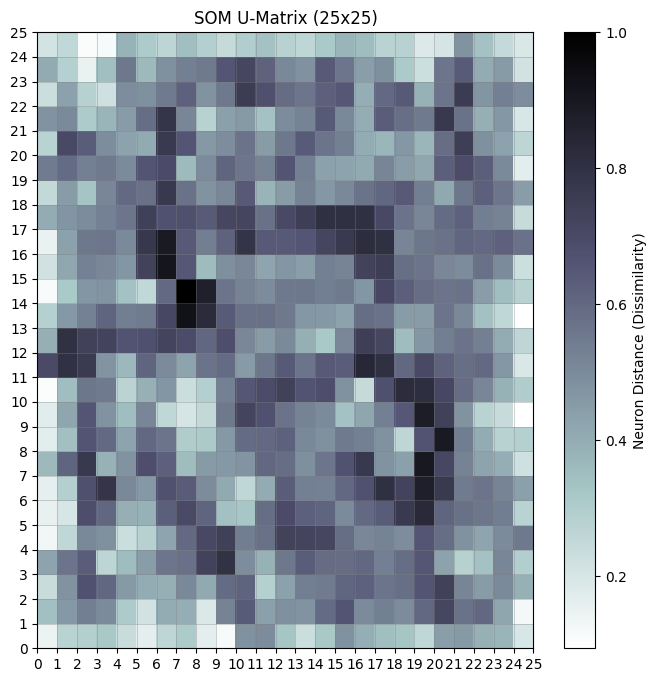

In [25]:
# --- U-Matrix Visualization ---

def plot_som_topology(som, grid_size):
    """
    Plots the Unified Distance Matrix (U-Matrix).
    Darker colors = Clusters (valleys).
    Lighter colors = Boundaries (ridges).
    """
    plt.figure(figsize=(8, 8))
    
    # 1. Get the U-Matrix (distance to neighbors)
    u_matrix = som.distance_map().T
    
    # 2. Plot heatmap
    plt.pcolor(u_matrix, cmap='bone_r') 
    plt.colorbar(label='Neuron Distance (Dissimilarity)')
    
    # Add grid lines
    plt.xticks(np.arange(grid_size[0] + 1))
    plt.yticks(np.arange(grid_size[1] + 1))
    plt.grid(color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    
    plt.title(f'SOM U-Matrix ({grid_size[0]}x{grid_size[1]})')
    plt.show()

# --- EXECUTION ---
plot_som_topology(som, (grid_size, grid_size))

In [54]:
# --- Two-Stage Clustering (SOM + K-Means) ---

# 1. Extract Weights (The "Prototypes")
# Reshape to (Num_Neurons, Num_Features)
weights = som.get_weights().reshape(-1, demographic_df.shape[1])

# 2. Find Best K for the Weights (Mini-Optimization)
print("Optimizing K-Means for SOM weights...")
best_k = 0
best_sil = -1
for k in range(4, 31): # Test small range suitable for map size
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(weights)
    sil = silhouette_score(weights, labels)
    print(f"K={k} -> Silhouette: {sil:.3f}")
    if sil > best_sil:
        best_sil = sil
        best_k = k

print(f"\nSelected K={best_k} for SOM Two-Stage Clustering.")

# 3. Final Clustering on Weights
km_som = KMeans(n_clusters=best_k, n_init=10, random_state=42)
neuron_clusters = km_som.fit_predict(weights)

# 4. Map Clusters back to Original Customers
# Strategy: Customer -> Best Matching Unit (Neuron) -> Neuron's Cluster
print("Mapping clusters back to customers...")
som_labels_demographic = []
X_data = demographic_df.values

for x in X_data:
    w = som.winner(x)
    # Flatten 2D coordinate (x,y) to 1D index
    idx = w[0] * grid_size + w[1]
    som_labels_demographic.append(neuron_clusters[idx])


Optimizing K-Means for SOM weights...
K=4 -> Silhouette: 0.170
K=5 -> Silhouette: 0.169
K=6 -> Silhouette: 0.175
K=7 -> Silhouette: 0.173
K=8 -> Silhouette: 0.199
K=9 -> Silhouette: 0.194
K=10 -> Silhouette: 0.197
K=11 -> Silhouette: 0.204
K=12 -> Silhouette: 0.209
K=13 -> Silhouette: 0.211
K=14 -> Silhouette: 0.220
K=15 -> Silhouette: 0.226
K=16 -> Silhouette: 0.221
K=17 -> Silhouette: 0.234
K=18 -> Silhouette: 0.234
K=19 -> Silhouette: 0.236
K=20 -> Silhouette: 0.243
K=21 -> Silhouette: 0.246
K=22 -> Silhouette: 0.253
K=23 -> Silhouette: 0.246
K=24 -> Silhouette: 0.245
K=25 -> Silhouette: 0.260
K=26 -> Silhouette: 0.262
K=27 -> Silhouette: 0.273
K=28 -> Silhouette: 0.263
K=29 -> Silhouette: 0.274
K=30 -> Silhouette: 0.275

Selected K=30 for SOM Two-Stage Clustering.
Mapping clusters back to customers...


In [55]:
# Save the labels to the customers DataFrame as demographic_cluster_labels
customers['demographic_cluster_labels'] = som_labels_demographic

In [56]:
# print head of customers to verify
customers.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,City,Latitude,Longitude,Postal code,Income,...,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,value_based_cluster_labels,behavioral_cluster_labels,demographic_cluster_labels
0,0.423255,Cecilia,Householder,Cecilia Householder,Canada,Toronto,0.037680,0.676108,M2Z 4K1,0.701593,...,1,0,0,0,0,0,1,0,0,1
1,0.499567,Dayle,Menez,Dayle Menez,Canada,Edmonton,0.595360,0.261899,T3G 6Y6,0.000000,...,0,0,0,0,0,0,0,0,0,28
2,0.366060,Necole,Hannon,Necole Hannon,Canada,Vancouver,0.355081,0.144954,V6E 3D9,0.000000,...,0,0,0,0,0,0,1,3,3,6
3,0.564856,Queen,Hagee,Queen Hagee,Canada,Toronto,0.037680,0.676108,P1W 1K4,0.000000,...,1,0,0,0,0,1,0,0,0,3
4,0.478339,Claire,Latting,Claire Latting,Canada,Hull,0.137786,0.720675,J8Y 3Z5,0.978506,...,0,0,1,0,0,1,0,5,0,20


# 3. Merge all Clustering Perspectives to one

In [64]:
# Identify all metric features in customers
metric_features = customers.select_dtypes(include=[np.number]).columns.tolist()

In [61]:
# unique labels in each clustering multiplied together
unique_value_based = customers['value_based_cluster_labels'].nunique()
unique_demographic = customers['demographic_cluster_labels'].nunique()
unique_behavioral = customers['behavioral_cluster_labels'].nunique()

unique_value_based * unique_demographic * unique_behavioral


2520

Apply Hierarchical Clustering on cluster centroids

In [66]:
#  Calculate centroids for each combination (only metric features)

df_centroids = customers.groupby(['value_based_cluster_labels', 'demographic_cluster_labels', 'behavioral_cluster_labels'])[metric_features].mean()
df_centroids.head()

Loyalty#  \
value_based_cluster_labels demographic_cluster_labels behavioral_cluster_labels             
0                          0                          0                          0.487658   
                           1                          0                          0.503255   
                           2                          0                          0.482788   
                           3                          0                          0.490710   
                           4                          0                          0.509064   

                                                                                 Latitude  \
value_based_cluster_labels demographic_cluster_labels behavioral_cluster_labels             
0                          0                          0                          0.390845   
                           1                          0                          0.074508   
                           2                          0                          0.155208   
                           3                          0                          0.073651   
                           4                          0                          0.364672   

                                                                                 Longitude  \
value_based_cluster_labels demographic_cluster_labels behavioral_cluster_labels              
0                          0                          0                           0.312247   
                           1                          0                           0.679112   
                           2                          0                           0.746069   
                           3                          0                           0.679172   
                           4                          0                           0.357570   

                                                                                   Income  \
value_based_cluster_labels demographic_cluster_labels behavioral_cluster_labels             
0                          0                          0                          0.478491   
                           1                          0                          0.511785   
                           2                          0                          0.481293   
                           3                          0                          0.174925   
                           4                          0                          0.501903   

                                                                                 Customer Lifetime Value  \
value_based_cluster_labels demographic_cluster_labels behavioral_cluster_labels                            
0                          0                          0                                         0.058057   
                           1                          0                                         0.059573   
                           2                          0                                         0.056572   
                           3                          0                                         0.045446   
                           4                          0                                         0.054173   

                                                                                 IsActive  \
value_based_cluster_labels demographic_cluster_labels behavioral_cluster_labels             
0                          0                          0                               1.0   
                           1                          0                               1.0   
                           2                          0                               1.0   
                           3                          0                               1.0   
                           4                          0                               1.0   

                                                         

In [67]:
print(f"\nCentroids shape: {df_centroids.shape}")


Centroids shape: (334, 41)


#### We will assume ward linkage 

#### But need to decide the number of final clusters 

In [68]:
# Fit hierarchical clustering with distance tracking
hclust = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    distance_threshold=0,
    n_clusters=None
)
hclust_labels = hclust.fit_predict(df_centroids)

# Build linkage matrix for dendrogram
# (Adapted from scikit-learn documentation)
counts = np.zeros(hclust.children_.shape[0])
n_samples = len(hclust.labels_)

for i, merge in enumerate(hclust.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples:
            current_count += 1  # Leaf node
        else:
            current_count += counts[child_idx - n_samples]
    counts[i] = current_count

linkage_matrix = np.column_stack([
    hclust.children_,
    hclust.distances_,
    counts
]).astype(float)

print("Linkage matrix ready for dendrogram!")

Linkage matrix ready for dendrogram!


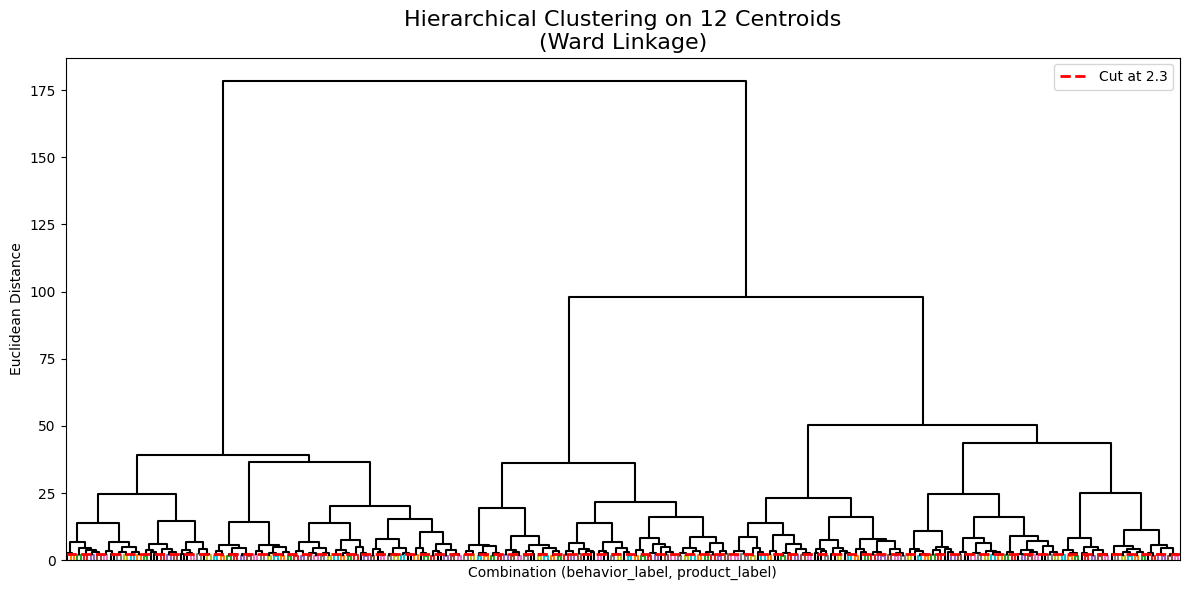

In [70]:
# Cell 18: Plot dendrogram with cutting options
fig = plt.figure(figsize=(12, 6))

# Potential cutting heights to consider
y_threshold = 2.3  # Can adjust this!

dendrogram(
    linkage_matrix,
    labels=df_centroids.index,
    color_threshold=y_threshold,
    above_threshold_color='k',
    no_labels=True  # Hide the labels on the x-axis
)

plt.axhline(y=y_threshold, color='r', linestyle='--', linewidth=2, label=f'Cut at {y_threshold}')

plt.title(f'Hierarchical Clustering on 12 Centroids\n(Ward Linkage)', fontsize=16)
plt.xlabel('Combination (behavior_label, product_label)')
plt.ylabel('Euclidean Distance')
plt.legend()
# plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [71]:
n_final_clusters = 8

hclust_final = AgglomerativeClustering(
    linkage='ward',
    n_clusters=n_final_clusters
)

hclust_final_labels = hclust_final.fit_predict(df_centroids)
hclust_final_labels

array([6, 6, 6, 6, 6, 6, 6, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6, 6, 6, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 6, 6, 6, 6, 6, 6,
       6, 6, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 7, 7, 7, 7, 7, 7, 7, 7,
       7, 7, 2, 2, 2, 2, 5, 5, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, 3, 3, 3, 3,
       3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 5, 5, 5, 5, 5, 5, 5, 1,
       1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 2, 2, 2, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 1, 1, 1, 3, 3, 3, 3, 3, 4, 4, 4, 4,
       4, 4, 4, 4, 2, 2, 2, 2, 5, 5, 5, 5, 5, 5, 5, 5, 5, 1, 1, 1, 1, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 2, 2, 2, 2, 5, 5, 5, 5, 5, 5,
       5, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2,
       2, 2, 5, 5, 5, 5, 5, 5, 5, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 5, 5, 5, 5, 1, 1, 1, 3, 3, 3, 3,
       3, 3, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2,

In [72]:
# Add to centroids dataframe
df_centroids['merged_labels'] = hclust_final_labels
df_centroids

Loyalty#  \
value_based_cluster_labels demographic_cluster_labels behavioral_cluster_labels             
0                          0                          0                          0.487658   
                           1                          0                          0.503255   
                           2                          0                          0.482788   
                           3                          0                          0.490710   
                           4                          0                          0.509064   
...                                                                                   ...   
11                         19                         5                          0.079639   
                           20                         5                          0.112734   
                           23                         5                          0.614784   
12                         10                         3                          0.572733   
13                         13                         3                          0.294619   

                                                                                 Latitude  \
value_based_cluster_labels demographic_cluster_labels behavioral_cluster_labels             
0                          0                          0                          0.390845   
                           1                          0                          0.074508   
                           2                          0                          0.155208   
                           3                          0                          0.073651   
                           4                          0                          0.364672   
...                                                                                   ...   
11                         19                         5                          0.062933   
                           20                         5                          0.141899   
                           23                         5                          0.037680   
12                         10                         3                          0.141899   
13                         13                         3                          0.037680   

                                                                                 Longitude  \
value_based_cluster_labels demographic_cluster_labels behavioral_cluster_labels              
0                          0                          0                           0.312247   
                           1                          0                           0.679112   
                           2                          0                           0.746069   
                           3                          0                           0.679172   
                           4                          0                           0.357570   
...                                                                                    ...   
11                         19                         5                           0.698051   
                           20                         5                           0.746738   
                           23                         5                           0.676108   
12                         10                         3                           0.746738   
13                         13                         3                           0.676108   

                                                                                   Income  \
value_based_cluster_labels demographic_cluster_labels behavioral_cluster_labels             
0                          0                          0                          0.478491   
                           1                          0                          0.511785   
                           2                          0           

In [76]:
# Cell 21: Map merged labels back to all customers

# We merge the customers dataframe with the df_centroids dataframe (which contains the 'merged_labels')
# We join on the 3 cluster labels which form the index of df_centroids
customers = customers.merge(
    df_centroids[['merged_labels']],
    left_on=['value_based_cluster_labels', 'demographic_cluster_labels', 'behavioral_cluster_labels'],
    right_index=True,
    how='left'
)

customers.head()

,Loyalty#,First Name,Last Name,Customer Name,Country,City,Latitude,Longitude,Postal code,Income,...,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,value_based_cluster_labels,behavioral_cluster_labels,demographic_cluster_labels,merged_labels
0,0.423255,Cecilia,Householder,Cecilia Householder,Canada,Toronto,0.037680,0.676108,M2Z 4K1,0.701593,...,0,0,0,0,0,1,0,0,1,6
1,0.499567,Dayle,Menez,Dayle Menez,Canada,Edmonton,0.595360,0.261899,T3G 6Y6,0.000000,...,0,0,0,0,0,0,0,0,28,7
2,0.366060,Necole,Hannon,Necole Hannon,Canada,Vancouver,0.355081,0.144954,V6E 3D9,0.000000,...,0,0,0,0,0,1,3,3,6,5
3,0.564856,Queen,Hagee,Queen Hagee,Canada,Toronto,0.037680,0.676108,P1W 1K4,0.000000,...,0,0,0,0,1,0,0,0,3,6
4,0.478339,Claire,Latting,Claire Latting,Canada,Hull,0.137786,0.720675,J8Y 3Z5,0.978506,...,0,1,0,0,1,0,5,0,20,3


In [77]:
print(customers['merged_labels'].value_counts().sort_index())

merged_labels
0    5745
1     510
2     428
3     864
4     408
5     843
6    3981
7    3596
Name: count, dtype: int64


In [81]:
# Quick distinctiveness check (R²)
r2_merged = get_rsq(customers, metric_features, 'merged_labels')
print(f"\nMerged clustering R²: {r2_merged:.4f}")


Merged clustering R²: 0.8245


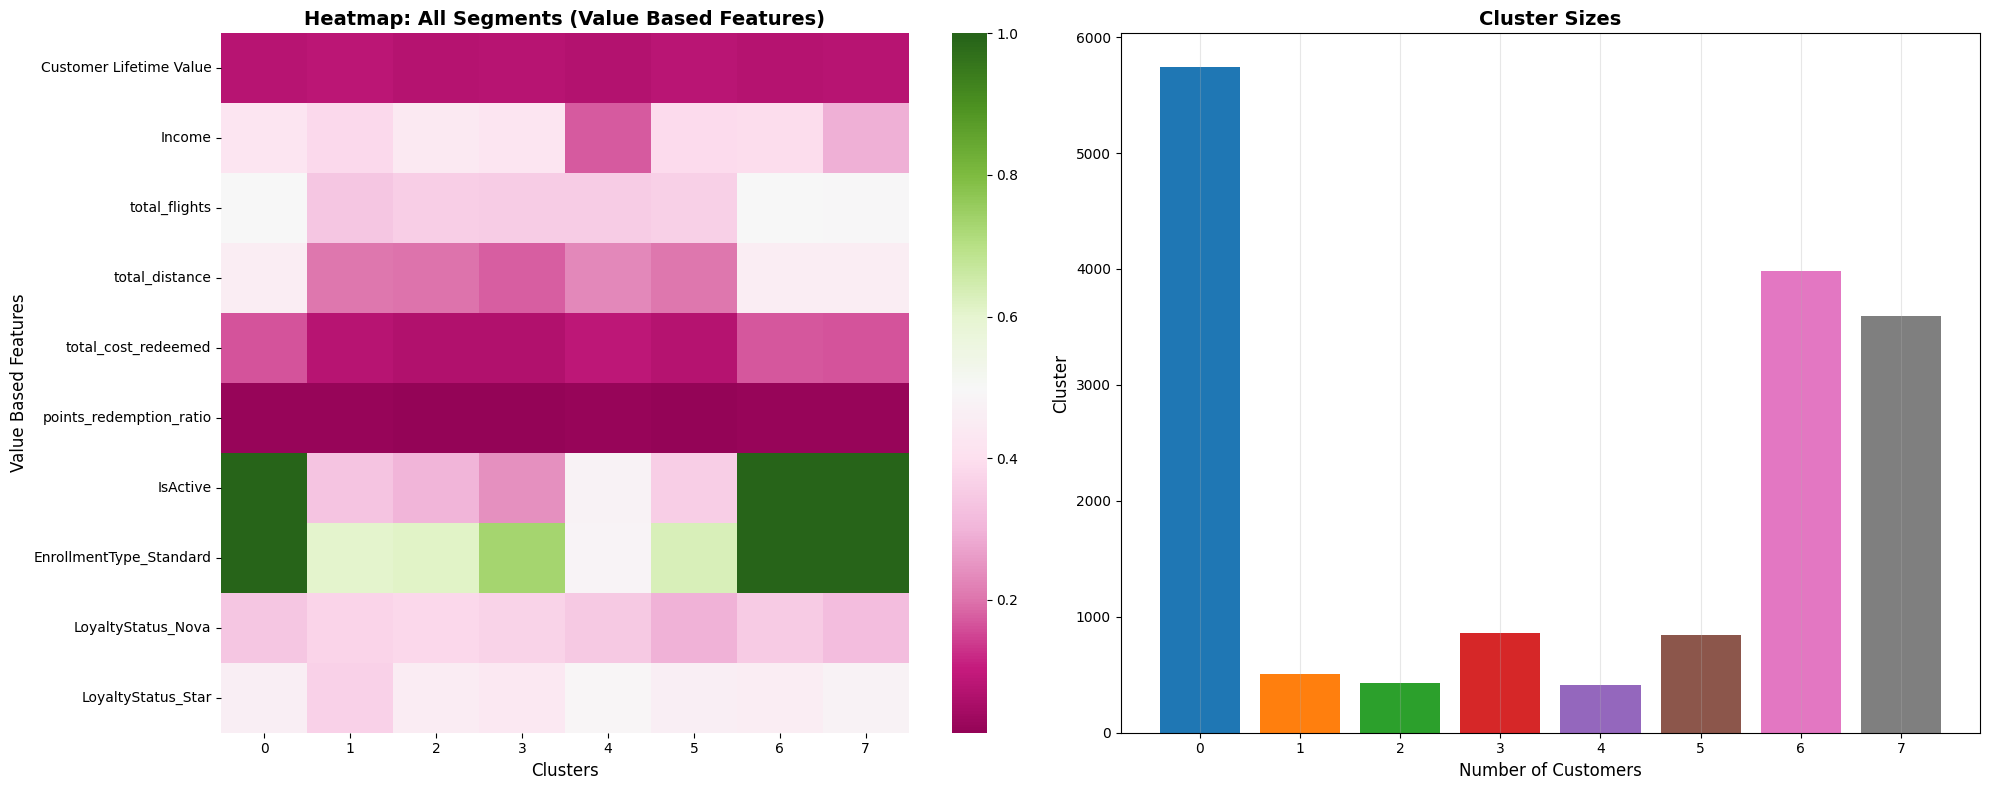

In [85]:
# ===========================================================
# Plot other type of visualization to profile the metric features
# ===========================================================

all_segments = sorted(customers['merged_labels'].unique())
# Use value_based_features instead of metric_features
df_all_centroids = customers.groupby('merged_labels')[value_based_features].mean().T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    df_all_centroids,
    cmap='PiYG',
    ax=ax1,
    center=0.5
)

ax1.set_title('Heatmap: All Segments (Value Based Features)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Value Based Features', fontsize=12)
ax1.set_xlabel('Clusters', fontsize=12)
ax1.grid(False)


cluster_sizes = customers['merged_labels'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=len(all_segments))

ax2.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
ax2.set_xlabel('Number of Customers', fontsize=12)
ax2.set_ylabel('Cluster', fontsize=12)
ax2.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()